## import libraries and load data

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [88]:
df = pd.read_excel("final_data_set.xlsx",sheet_name="Fact_SurveyResponses")

## Explore the Data

In [89]:
df.head()

,age,gender,status,daily screen time hours,daily social media hours,physical exercise,sleep hour,check phone morning,irritable recently,top apps,doomscroll level,ContentFormat_ID,StayFactor_ID,SkipPoint_KEY,VisualEffect_Key
0,18-24,Male,S,More than 8 hours,1 – 3 hours,I was playing and I stopped,5 – 6 hours,Always,No,Instagram,1,VID_SHORT,TONE_STYLE,SKIP_PACE,YES_SIG
1,18-24,Male,S,More than 8 hours,5 – 7 hours,I was playing and I stopped,6 – 7 hours,Always,Yes,WhatsApp,2,STORY_REAL,TONE_STYLE,SKIP_INTEREST,YES_SIG
2,18-24,Female,S,More than 8 hours,3 – 5 hours,I was playing and I stopped,More than 8 hours,Always,Yes,Instagram,2,STORY_REAL,TONE_STYLE,SKIP_PACE,NO_CONTENT
3,18-24,Female,S,More than 8 hours,3 – 5 hours,Yes,More than 8 hours,Always,No,Tiktok,2,VID_SHORT,VISUAL_MQ,SKIP_INTEREST,YES_SIG
4,18-24,Male,S,6 - 8 hours,3 – 5 hours,No,More than 8 hours,Always,No,Facebook,3,VID_SHORT,VISUAL_MQ,SKIP_PACE,NO_CONTENT


In [90]:
df.shape

(217, 15)

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   age                       217 non-null    object
 1   gender                    217 non-null    object
 2   status                    217 non-null    object
 3   daily screen time hours   217 non-null    object
 4   daily social media hours  217 non-null    object
 5   physical exercise         217 non-null    object
 6   sleep hour                217 non-null    object
 7   check phone morning       217 non-null    object
 8   irritable recently        217 non-null    object
 9   top apps                  217 non-null    object
 10  doomscroll level          217 non-null    int64 
 11  ContentFormat_ID          217 non-null    object
 12  StayFactor_ID             217 non-null    object
 13  SkipPoint_KEY             217 non-null    object
 14  VisualEffect_Key          

In [92]:
df.isnull().sum()

age                         0
gender                      0
status                      0
daily screen time hours     0
daily social media hours    0
physical exercise           0
sleep hour                  0
check phone morning         0
irritable recently          0
top apps                    0
doomscroll level            0
ContentFormat_ID            0
StayFactor_ID               0
SkipPoint_KEY               0
VisualEffect_Key            0
dtype: int64

In [93]:
df.duplicated().sum()

np.int64(3)

In [94]:
df.columns

Index(['age', 'gender', 'status', 'daily screen time hours',
       'daily social media hours', 'physical exercise', 'sleep hour',
       'check phone morning', 'irritable recently', 'top apps',
       'doomscroll level', 'ContentFormat_ID', 'StayFactor_ID',
       'SkipPoint_KEY', 'VisualEffect_Key'],
      dtype='object')

In [95]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
doomscroll level,217.0,1.732719,0.640087,1.0,1.0,2.0,2.0,3.0


In [96]:
df.describe(include='object').T

,count,unique,top,freq
age,217,6,18-24,170
gender,217,2,Male,128
status,217,4,S,152
daily screen time hours,217,5,6 - 8 hours,65
daily social media hours,217,5,1 – 3 hours,76
physical exercise,217,3,I was playing and I stopped,97
sleep hour,217,5,5 – 6 hours,64
check phone morning,217,3,Always,129
irritable recently,217,3,No,96
top apps,217,9,Facebook,66


After an initial check, we identified several areas that require adjustment:

1. **Column Data Types**: Certain columns, such as `"age"` and `"gender"`, are currently stored as `object`. It is recommended to convert them to `category` for better data handling and analysis.

2. **Duplicate Records**: The dataset contains duplicate entries, which will be removed to ensure data integrity.

## Handle the problems

In [97]:
# remove duplicates
df=df.drop_duplicates(keep='first')

In [98]:
df.duplicated().sum()

np.int64(0)

In [99]:
# change data types for columns
category_cols = ['age', 'gender', 'status', 'daily screen time hours', 'daily social media hours',
            'physical exercise', 'sleep hour', 'check phone morning', 'irritable recently']
for col in category_cols:
    df[col] = df[col].astype('category')

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 214 entries, 0 to 216
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   age                       214 non-null    category
 1   gender                    214 non-null    category
 2   status                    214 non-null    category
 3   daily screen time hours   214 non-null    category
 4   daily social media hours  214 non-null    category
 5   physical exercise         214 non-null    category
 6   sleep hour                214 non-null    category
 7   check phone morning       214 non-null    category
 8   irritable recently        214 non-null    category
 9   top apps                  214 non-null    object  
 10  doomscroll level          214 non-null    int64   
 11  ContentFormat_ID          214 non-null    object  
 12  StayFactor_ID             214 non-null    object  
 13  SkipPoint_KEY             214 non-null    object  
 14 

# Data Cleaning and Preprocessing Summary

After reviewing the dataset, the following adjustments have been applied:

1. **Column Data Type Conversion**  
   - Converted several columns from `object` to `category` for better analysis and memory efficiency.  
   - Columns updated:  
     - `"age"`  
     - `"gender"`  
     - `"status"`  
     - `"daily screen time hours"`  
     - `"daily social media hours"`  
     - `"physical exercise"`  
     - `"sleep hour"`  
     - `"check phone morning"`  
     - `"irritable recently"`  

3. **Duplicate Removal**  
   - Identified and removed duplicate rows to maintain data integrity.



## EDA

In [101]:
df['doomscroll level'].value_counts()

doomscroll level
2    111
1     81
3     22
Name: count, dtype: int64

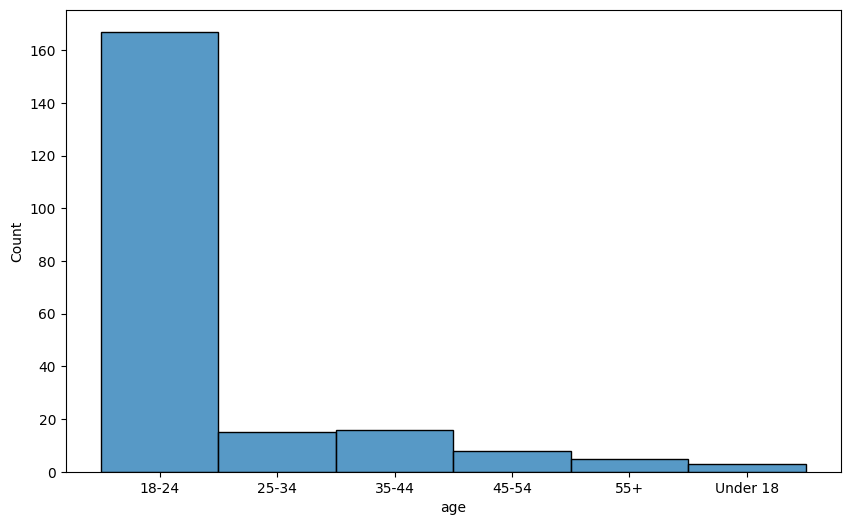

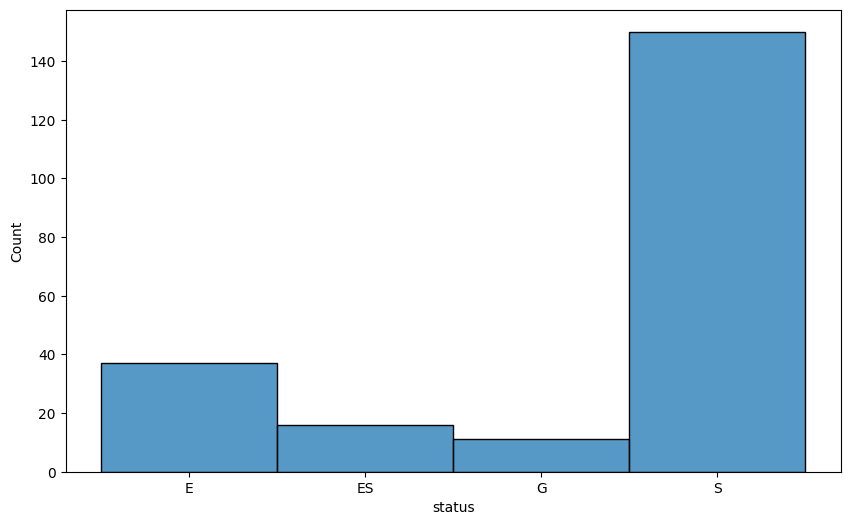

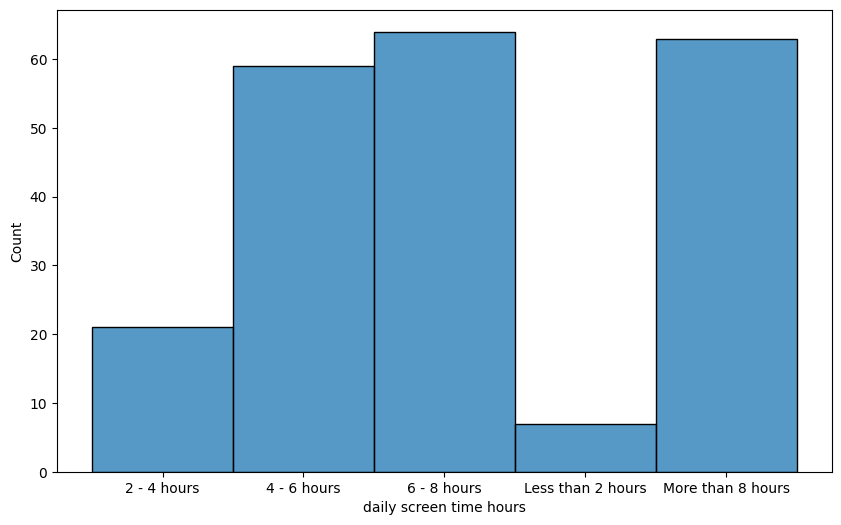

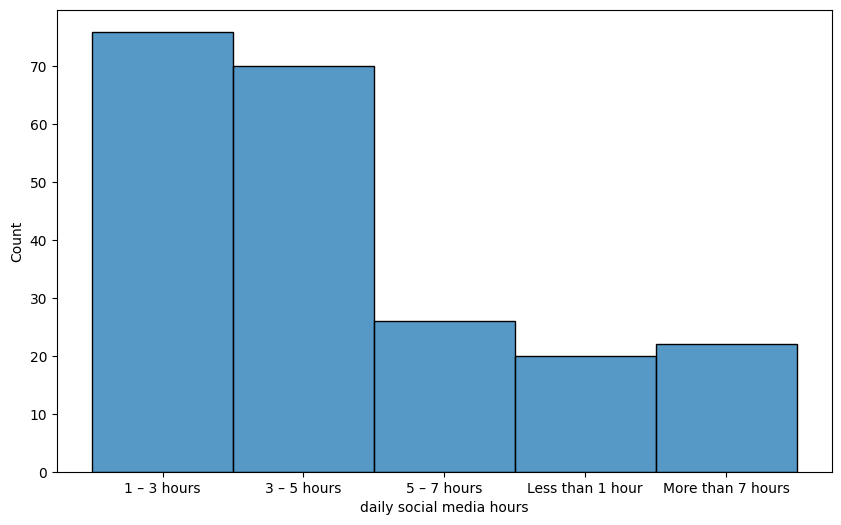

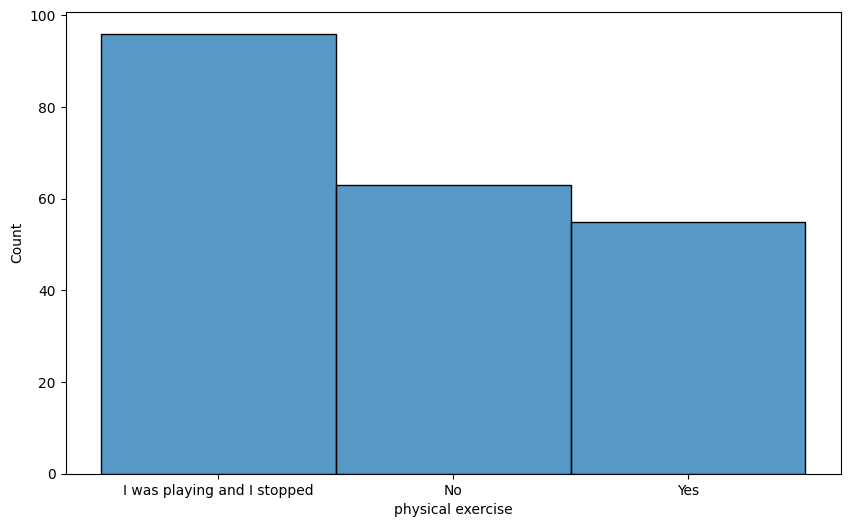

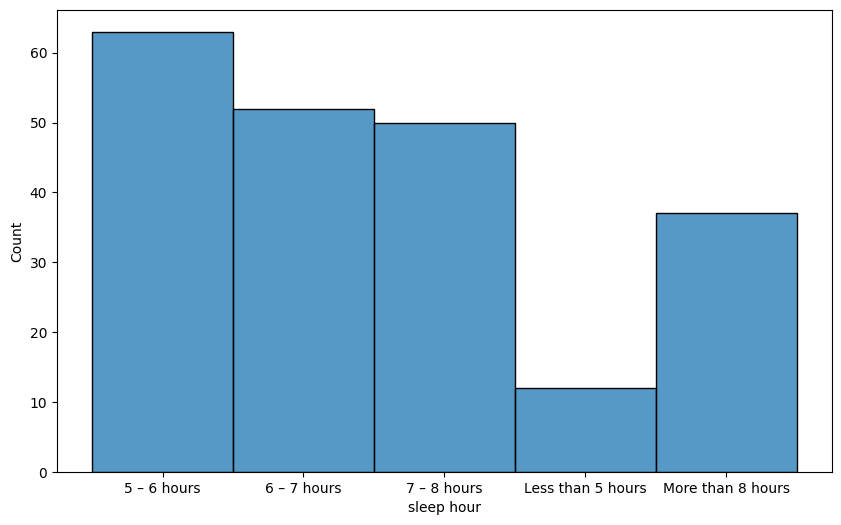

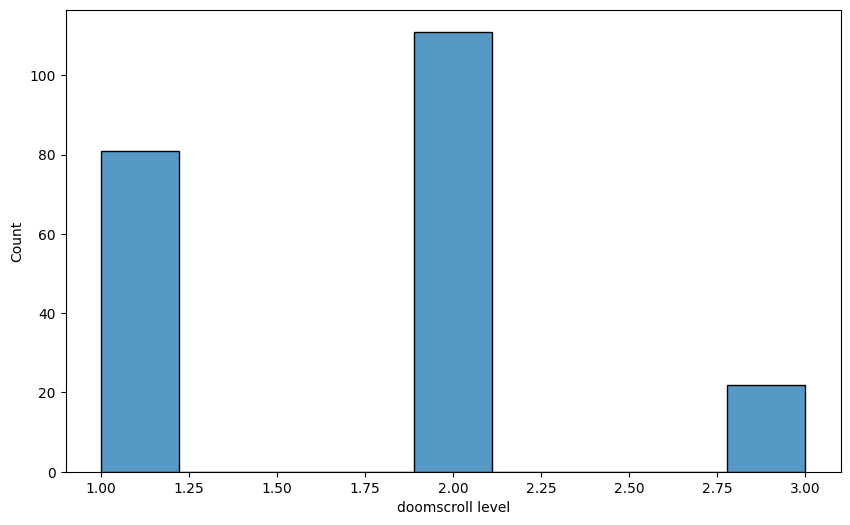

In [102]:
# histogram to distribution
columns_for_histogram = [
    "age",
    "status",
    "daily screen time hours",
    "daily social media hours",
    "physical exercise",
    "sleep hour",
    "doomscroll level"
]
for i in columns_for_histogram:
    plt.figure(figsize=(10,6)) 
    sns.histplot(data=df,x=i)
    plt.show()

# Data Insights from the histograms

Based on the visualizations, we can observe the following patterns:

1. **Demographics**: The majority of participants belong to Generation Z and are currently students.  

2. **Screen Usage**: Most participants exhibit high daily screen time, while their social media usage remains moderate. This suggests that a significant portion of their screen time may be dedicated to work or study activities.  

3. **Physical Activity**: Many participants are currently inactive in terms of sports, although they were active in the past.  

4. **Doomscrolling Behavior**: Most participants display a moderate level of doomscrolling.

In [103]:
df.columns.tolist()

['age',
 'gender',
 'status',
 'daily screen time hours',
 'daily social media hours',
 'physical exercise',
 'sleep hour',
 'check phone morning',
 'irritable recently',
 'top apps',
 'doomscroll level',
 'ContentFormat_ID',
 'StayFactor_ID',
 'SkipPoint_KEY',
 'VisualEffect_Key']

## Feature Engineering

In [104]:
# categorize the values of screen time
screen_time_map = {
    'Less than 2 hours': 'Very Low',
    '2 - 4 hours': 'Low',
    '4 - 6 hours': 'Medium',
    '6 - 8 hours': 'High',
    'More than 8 hours': 'Very High'
}
df['screen_time_level'] = df['daily screen time hours'].map(screen_time_map)

In [105]:
# categorize the values of sleep hours
sleep_hours_map = {
    'Less than 5 hours':"very Low",
    '5 – 6 hours': 'Low',
    '6 – 7 hours': 'Good',
    '7 – 8 hours': 'High',
    'More than 8 hours': 'Very High'
}
df['sleep_level'] = df['sleep hour'].map(sleep_hours_map)

In [106]:
df['sleep hour'].value_counts()

sleep hour
5 – 6 hours          63
6 – 7 hours          52
7 – 8 hours          50
More than 8 hours    37
Less than 5 hours    12
Name: count, dtype: int64

In [107]:
# get the value from screen time hours ranges
screen_time_map = {
    'Less than 2 hours': 1,
    '2 - 4 hours': 2,
    '4 - 6 hours': 3,
    '6 - 8 hours': 4,
    'More than 8 hours': 5
}
df['screen_time_score'] = df['daily screen time hours'].map(screen_time_map)

In [108]:
# get the value from social media hours ranges
social_hours_map = {
    'Less than 1 hour':1,
    '1 – 3 hours': 2,
    '3 – 5 hours': 3,
    '5 – 7 hours': 4,
    'More than 7 hours': 5
}
df['social_media_score'] = df['daily social media hours'].map(social_hours_map)

In [109]:
df.head()

,age,gender,status,daily screen time hours,daily social media hours,physical exercise,sleep hour,check phone morning,irritable recently,top apps,doomscroll level,ContentFormat_ID,StayFactor_ID,SkipPoint_KEY,VisualEffect_Key,screen_time_level,sleep_level,screen_time_score,social_media_score
0,18-24,Male,S,More than 8 hours,1 – 3 hours,I was playing and I stopped,5 – 6 hours,Always,No,Instagram,1,VID_SHORT,TONE_STYLE,SKIP_PACE,YES_SIG,Very High,Low,5,2
1,18-24,Male,S,More than 8 hours,5 – 7 hours,I was playing and I stopped,6 – 7 hours,Always,Yes,WhatsApp,2,STORY_REAL,TONE_STYLE,SKIP_INTEREST,YES_SIG,Very High,Good,5,4
2,18-24,Female,S,More than 8 hours,3 – 5 hours,I was playing and I stopped,More than 8 hours,Always,Yes,Instagram,2,STORY_REAL,TONE_STYLE,SKIP_PACE,NO_CONTENT,Very High,Very High,5,3
3,18-24,Female,S,More than 8 hours,3 – 5 hours,Yes,More than 8 hours,Always,No,Tiktok,2,VID_SHORT,VISUAL_MQ,SKIP_INTEREST,YES_SIG,Very High,Very High,5,3
4,18-24,Male,S,6 - 8 hours,3 – 5 hours,No,More than 8 hours,Always,No,Facebook,3,VID_SHORT,VISUAL_MQ,SKIP_PACE,NO_CONTENT,High,Very High,4,3


In [110]:
# change data types for the new columns
df['screen_time_score']=df['screen_time_score'].astype('Int32')
df['social_media_score']=df['social_media_score'].astype('float64')
# make a new column to calculate the percentage of social media usage from total screen time
df['social_media'] = (df['social_media_score'] / df['screen_time_score'])*100

In [111]:
df['social_media'].max()

np.float64(250.0)

In [112]:
# categorize the percentage of social media usage from total screen time
df['social_media_level'] = pd.cut(
    df['social_media'],
    bins=[0, 25, 50, 75, 300],
    labels=['Low ', 'Moderate ', 'High', 'Extreme']
)
df['social_media_level'].value_counts()

social_media_level
Extreme      98
High         64
Moderate     46
Low           6
Name: count, dtype: int64

In [113]:
# create a new column to identify individuals with high screen time and low sleep
df['high_screen_low_sleep'] = df.apply(
    lambda x: 1 if (x['screen_time_level'] in ['High', 'Very High']) 
                   and (x['sleep_level'] in ['Low', 'Very Low']) 
              else 0,
    axis=1
)

In [114]:
# create a new column to identify individuals with high doomscrolling and low sleep
df['high_doomscroll_low_sleep'] = df.apply(
    lambda x: 1 if (x['sleep_level'] in ['Low', 'Very Low']) 
                   and (x['doomscroll level'] == 3) 
              else 0,
    axis=1
    )

In [115]:
# drop the intermediate columns used for calculations
df.drop(columns=['screen_time_score','social_media_score','social_media'],inplace=True)

In [116]:
df.head()

,age,gender,status,daily screen time hours,daily social media hours,physical exercise,sleep hour,check phone morning,irritable recently,top apps,doomscroll level,ContentFormat_ID,StayFactor_ID,SkipPoint_KEY,VisualEffect_Key,screen_time_level,sleep_level,social_media_level,high_screen_low_sleep,high_doomscroll_low_sleep
0,18-24,Male,S,More than 8 hours,1 – 3 hours,I was playing and I stopped,5 – 6 hours,Always,No,Instagram,1,VID_SHORT,TONE_STYLE,SKIP_PACE,YES_SIG,Very High,Low,Moderate,1,0
1,18-24,Male,S,More than 8 hours,5 – 7 hours,I was playing and I stopped,6 – 7 hours,Always,Yes,WhatsApp,2,STORY_REAL,TONE_STYLE,SKIP_INTEREST,YES_SIG,Very High,Good,Extreme,0,0
2,18-24,Female,S,More than 8 hours,3 – 5 hours,I was playing and I stopped,More than 8 hours,Always,Yes,Instagram,2,STORY_REAL,TONE_STYLE,SKIP_PACE,NO_CONTENT,Very High,Very High,High,0,0
3,18-24,Female,S,More than 8 hours,3 – 5 hours,Yes,More than 8 hours,Always,No,Tiktok,2,VID_SHORT,VISUAL_MQ,SKIP_INTEREST,YES_SIG,Very High,Very High,High,0,0
4,18-24,Male,S,6 - 8 hours,3 – 5 hours,No,More than 8 hours,Always,No,Facebook,3,VID_SHORT,VISUAL_MQ,SKIP_PACE,NO_CONTENT,High,Very High,High,0,0


# Feature Engineering Overview



##  Added / Engineered Features

| New Column Name | Source Column(s) | Description |
|-----------------|-----------------|-------------|
| screen_time_level | daily screen time hours | Categorizes daily screen time into levels such as Very Low, Low, Medium, High, Very High |
| social_media_level | daily social media hours | Categorizes social media usage into levels such as Low, Medium, High, Very High |
| sleep_level | sleep hour | Categorizes sleep duration into levels such as Very Low, Low, Medium, High, Very High |
| social_media | daily screen time hours + daily social media hours | Percentage of daily social media usage relative to total screen time |
| social_media_level | social_media_ratio | Categorizes social media usage percentage into Low, Moderate, High, Extreme |
| doomscroll_category | doomscroll level | Categorizes doomscrolling intensity into Low, Medium, High |
| high_screen_low_sleep | screen_time_level + sleep_level | Binary feature: 1 if screen time is High/Very High and sleep is Low/Very Low, else 0 |
| high_doomscroll_low_sleep | sleep_level + doomscroll_category | Binary feature: 1 if sleep is Low/Very Low and doomscroll is High, else 0 |

---

### 🔹 Notes

- `_level` columns retain the **categorical meaning** of the original ranges without converting them to raw numeric values.  
- `_ratio` column is numeric and represents a proportion ready for analysis.  
- Binary combined features capture **high-risk behavior patterns** useful for modeling or behavioral analysis.

In [117]:
df.head()

,age,gender,status,daily screen time hours,daily social media hours,physical exercise,sleep hour,check phone morning,irritable recently,top apps,doomscroll level,ContentFormat_ID,StayFactor_ID,SkipPoint_KEY,VisualEffect_Key,screen_time_level,sleep_level,social_media_level,high_screen_low_sleep,high_doomscroll_low_sleep
0,18-24,Male,S,More than 8 hours,1 – 3 hours,I was playing and I stopped,5 – 6 hours,Always,No,Instagram,1,VID_SHORT,TONE_STYLE,SKIP_PACE,YES_SIG,Very High,Low,Moderate,1,0
1,18-24,Male,S,More than 8 hours,5 – 7 hours,I was playing and I stopped,6 – 7 hours,Always,Yes,WhatsApp,2,STORY_REAL,TONE_STYLE,SKIP_INTEREST,YES_SIG,Very High,Good,Extreme,0,0
2,18-24,Female,S,More than 8 hours,3 – 5 hours,I was playing and I stopped,More than 8 hours,Always,Yes,Instagram,2,STORY_REAL,TONE_STYLE,SKIP_PACE,NO_CONTENT,Very High,Very High,High,0,0
3,18-24,Female,S,More than 8 hours,3 – 5 hours,Yes,More than 8 hours,Always,No,Tiktok,2,VID_SHORT,VISUAL_MQ,SKIP_INTEREST,YES_SIG,Very High,Very High,High,0,0
4,18-24,Male,S,6 - 8 hours,3 – 5 hours,No,More than 8 hours,Always,No,Facebook,3,VID_SHORT,VISUAL_MQ,SKIP_PACE,NO_CONTENT,High,Very High,High,0,0


In [118]:
# save the data
df.to_csv("survey_data_edited.csv", index=False)

In [120]:
df.isnull().sum()

age                          0
gender                       0
status                       0
daily screen time hours      0
daily social media hours     0
physical exercise            0
sleep hour                   0
check phone morning          0
irritable recently           0
top apps                     0
doomscroll level             0
ContentFormat_ID             0
StayFactor_ID                0
SkipPoint_KEY                0
VisualEffect_Key             0
screen_time_level            0
sleep_level                  0
social_media_level           0
high_screen_low_sleep        0
high_doomscroll_low_sleep    0
dtype: int64

In [121]:
df.head()

,age,gender,status,daily screen time hours,daily social media hours,physical exercise,sleep hour,check phone morning,irritable recently,top apps,doomscroll level,ContentFormat_ID,StayFactor_ID,SkipPoint_KEY,VisualEffect_Key,screen_time_level,sleep_level,social_media_level,high_screen_low_sleep,high_doomscroll_low_sleep
0,18-24,Male,S,More than 8 hours,1 – 3 hours,I was playing and I stopped,5 – 6 hours,Always,No,Instagram,1,VID_SHORT,TONE_STYLE,SKIP_PACE,YES_SIG,Very High,Low,Moderate,1,0
1,18-24,Male,S,More than 8 hours,5 – 7 hours,I was playing and I stopped,6 – 7 hours,Always,Yes,WhatsApp,2,STORY_REAL,TONE_STYLE,SKIP_INTEREST,YES_SIG,Very High,Good,Extreme,0,0
2,18-24,Female,S,More than 8 hours,3 – 5 hours,I was playing and I stopped,More than 8 hours,Always,Yes,Instagram,2,STORY_REAL,TONE_STYLE,SKIP_PACE,NO_CONTENT,Very High,Very High,High,0,0
3,18-24,Female,S,More than 8 hours,3 – 5 hours,Yes,More than 8 hours,Always,No,Tiktok,2,VID_SHORT,VISUAL_MQ,SKIP_INTEREST,YES_SIG,Very High,Very High,High,0,0
4,18-24,Male,S,6 - 8 hours,3 – 5 hours,No,More than 8 hours,Always,No,Facebook,3,VID_SHORT,VISUAL_MQ,SKIP_PACE,NO_CONTENT,High,Very High,High,0,0
